In [1]:
from openpmd_api import Series, Access
import matplotlib.pyplot as plt
import numpy as np

In [2]:
series = Series("diags/diag/openpmd_%T.h5", Access.read_only)
its = sorted(series.iterations)
it = series.iterations[its[-1]]      # iteration 10

B = it.meshes["B"]
Bx = B["x"].load_chunk()
By = B["y"].load_chunk()
Bz = B["z"].load_chunk()
series.flush()
#B2 = Bx**2 + By**2 + Bz**2

shape  = B["x"].shape            # cells per axis, e.g. [Nz, Nr] in RZ
dx     = B.grid_spacing          # cell size along each axis
x0     = B.grid_global_offset    # lower corner of the grid
axes   = B.axis_labels           # e.g. ('z', 'r') or ('x','y','z')
unit   = B.grid_unit_SI          # multiply spacing/offset by this for meters
geom   = B.geometry              # cartesian / thetaMode / etc.

# physical extents (in SI meters)
lo = [o * unit for o in x0]
hi = [(o + n * d) * unit for o, n, d in zip(x0, shape, dx)]

coords = [x0[i]*unit + (np.arange(shape[i]) + B["x"].position[i]) * dx[i] * unit for i in range(len(shape))][0]

In [3]:
print(coords.shape)
print(Bx.shape)

(64,)
(64, 64)


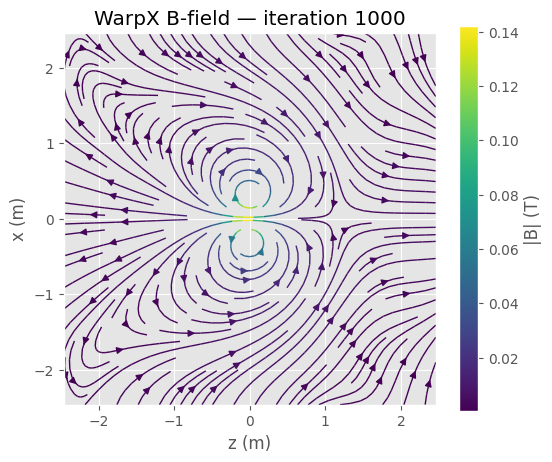

In [4]:
mag = np.hypot(Bx, Bz)

fig, ax = plt.subplots(figsize=(6, 5))
strm = ax.streamplot(
    coords, coords, Bx, Bz,
    color=mag, cmap="viridis", density=1.2, linewidth=1,
)
cb = fig.colorbar(strm.lines, ax=ax)
cb.set_label("|B| (T)")
ax.set_xlabel("z (m)")
ax.set_ylabel("x (m)")
ax.set_title(f"WarpX B-field — iteration {its[-1]}")
ax.set_aspect("equal")
plt.show()

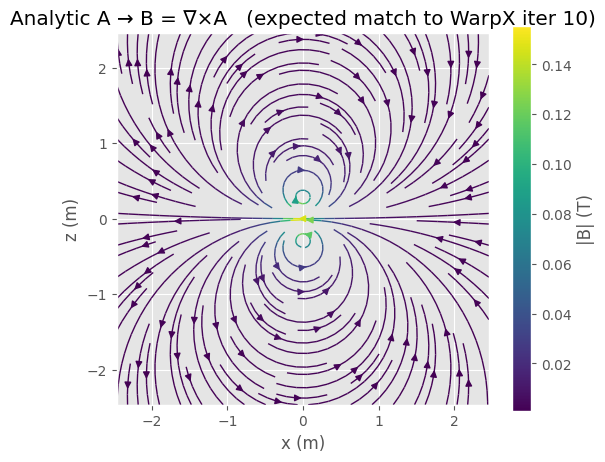

RMS rel error vs WarpX iter 2:
  Bx : 1.102e+00
  Bz : 6.168e-01
  |B|: 2.800e-01


In [5]:
# Constants from inputs/coil 2D/coil_2d.py (external_vector_potential.dipole):
#   K      vector-potential amplitude (T·m)
#   dh     half-separation between the two line currents (m)
#   eps    softening that keeps Ay finite on the line currents (m)
K   = 0.01
dh  = 0.25
eps = np.sqrt(0.006084)        # ≈ 0.078 m (matches eps² = 0.006084 in the run)


def Ay_analytic(x, z):
    """Static external A_y(x, z) used by the coil_2D run.

    Ax = Az = 0 by construction. Vectorised — `x` and `z` can be arrays of
    any matching shape.
    """
    return K * np.log(
        (x * x + (z + dh) ** 2 + eps * eps) /
        (x * x + (z - dh) ** 2 + eps * eps)
    )


# Build both axis coordinates from the openPMD metadata loaded earlier so
# the analytic grid is byte-identical to the WarpX one. axes[0] is x,
# axes[1] is z for this 2D Cartesian run.
xs = x0[0] * unit + (np.arange(shape[0]) + B["x"].position[0]) * dx[0] * unit
zs = x0[1] * unit + (np.arange(shape[1]) + B["x"].position[1]) * dx[1] * unit
X, Z = np.meshgrid(xs, zs, indexing="ij")

# Evaluate Ay on the grid and take its curl numerically. np.gradient uses
# second-order central differences in the interior — the same stencil
# class WarpX's Yee curl uses, so any deviation from the WarpX diagnostic
# at iteration 10 isolates the plasma-current contribution.
Ay_grid = Ay_analytic(X, Z)
dAy_dx = np.gradient(Ay_grid, xs, axis=0)
dAy_dz = np.gradient(Ay_grid, zs, axis=1)
Bx_an = -dAy_dz
Bz_an = +dAy_dx

mag_an = np.hypot(Bx_an, Bz_an).T

fig, ax = plt.subplots(figsize=(6, 5))
strm = ax.streamplot(
    xs, zs, Bx_an.T, Bz_an.T,
    color=mag_an, cmap="viridis", density=1.2, linewidth=1,
)
cb = fig.colorbar(strm.lines, ax=ax)
cb.set_label("|B| (T)")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_title("Analytic A → B = ∇×A   (expected match to WarpX iter 10)")
ax.set_aspect("equal")
plt.show()

# Quick numerical comparison against the WarpX snapshot already loaded
# above (Bx, Bz at iteration 10). The agreement won't be exact — 10
# hybrid steps have accumulated a small plasma-current contribution —
# but RMS rel error should be well under 10% if the grid and the formula
# match correctly.
def _rms_rel(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)) /
                 max(np.sqrt(np.mean(b ** 2)), 1e-30))

print(f"RMS rel error vs WarpX iter {its[1]}:")
print(f"  Bx : {_rms_rel(Bx_an, Bx):.3e}")
print(f"  Bz : {_rms_rel(Bz_an, Bz):.3e}")
print(f"  |B|: {_rms_rel(np.hypot(Bx_an, Bz_an), np.hypot(Bx, Bz)):.3e}")

## Compare the thing to magpylib

In [6]:
import magpylib as mp
from magpylib.current import Circle

bounds = 2.5 # m
ring_pos = (0,0,0)
ring_dia = 0.5 # m
ring_current = -1e5 # A

# make a circle coil aligned in the y-z plane
C = Circle(position=ring_pos, diameter=ring_dia, current=ring_current).rotate_from_angax(90, [0, 1, 0])

# Local coord array — kept _mag-suffixed so this cell never clobbers the
# `coords` defined above from the openPMD grid (which downstream β / leakage
# cells rely on).
coords_mag = np.linspace(-bounds, bounds, 100)

# get B-field from the grid
_grid = np.meshgrid(coords_mag, np.zeros(100), coords_mag, indexing='ij') # y-axis is always 0
grid = np.moveaxis(_grid, 0, -1)

B_mag_grid = C.getB(grid)
Bx_mag, By_mag, Bz_mag = np.moveaxis(B_mag_grid, -1, 0)

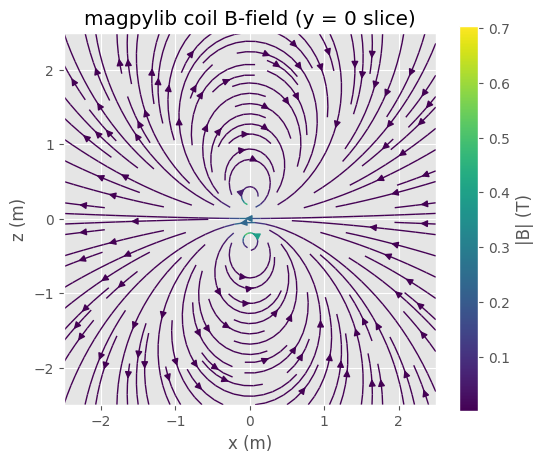

In [7]:
Bx_slice = Bx_mag[:, 0, :]
Bz_slice = Bz_mag[:, 0, :]
mag = np.hypot(Bx_slice, Bz_slice).T

fig, ax = plt.subplots(figsize=(6, 5))
strm = ax.streamplot(
    coords_mag, coords_mag, Bx_slice.T, Bz_slice.T,
    color=mag, cmap="viridis", density=1.2, linewidth=1,
)
cb = fig.colorbar(strm.lines, ax=ax)
cb.set_label("|B| (T)")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_title("magpylib coil B-field (y = 0 slice)")
ax.set_aspect("equal")
plt.show()

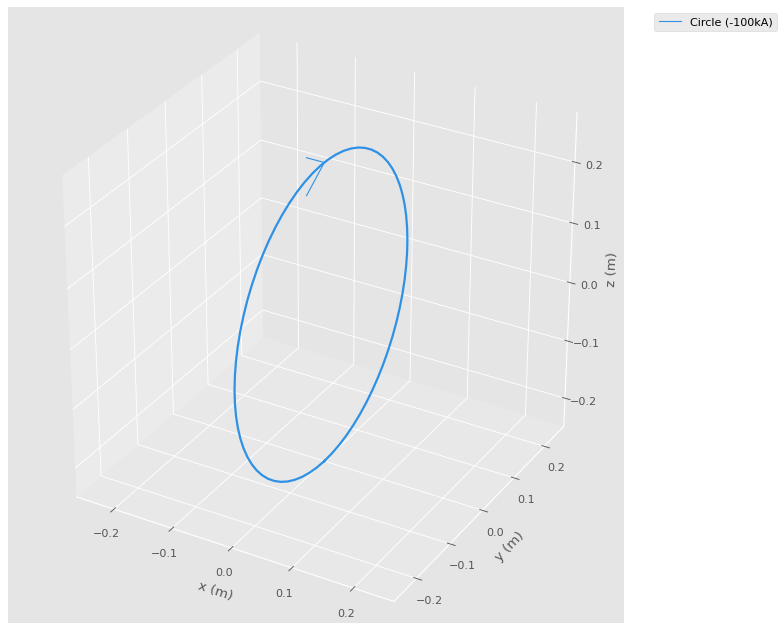

In [8]:
mp.show(C, backend="matplotlib")

## Pressure-balance diagnostics: β and the ram-pressure standoff

The coil_2D run is built to find the Chapman–Ferraro standoff — the surface where upstream ram pressure balances the dipole's magnetic pressure. Four pressures per cell carry the diagnostic:

- **Magnetic**: $p_{\text{mag}} = (B_x^2 + B_y^2 + B_z^2) / (2\mu_0)$ — direct from the field mesh.
- **Electron (fluid)**: $p_e = n_e T_e (n_e/n_0)^{\gamma-1}$ — $T_e$, $n_0$, $\gamma$ are solver inputs (must match `HybridPICSolver(Te=…, n0=…, gamma=…)` in the deck).
- **Ion thermal**: $p_{i,\text{th}} = \tfrac{1}{3} n_i m_i \sigma_v^2$ — needs the velocity variance per cell, binned from the particle dumps.
- **Ion ram**: $p_{\text{ram}} = n_i m_i \|\langle \mathbf{v} \rangle\|^2$ — needs the bulk velocity per cell, also from binning.

$n_i$ is taken from the deposited `rho_background_i + rho_stream_i` (better than re-binning — WarpX's deposition shape function is built in). $n_e = n_i$ by quasi-neutrality in hybrid PIC.

Plasma β is then $\beta_{\text{th}} = (p_{i,\text{th}} + p_e)/p_{\text{mag}}$ and $\beta_{\text{dyn}} = p_{\text{ram}}/p_{\text{mag}}$. The **$\beta_{\text{dyn}} = 1$ contour** is the empirical standoff surface — compare to the analytic `r_CF` printed at run start.

In [9]:
import openpmd_api as io
import scipy.constants as sc

# --- Solver-side inputs that aren't in the diagnostic.
# Must match inputs/coil 2D/coil_2d.py — HybridPICSolver(Te=..., n0=..., gamma=...)
# and the stream parameters (n_stream, v_drift). Keep these in sync with the deck:
#   n0      = n_stream   (electron-pressure closure reference density)
#   v_drift = stream injection speed (for the ram-pressure sanity reference)
mu0, m_i, q_i = sc.mu_0, sc.m_p, sc.e
T_e_J   = 10.0 * sc.eV
gamma   = 5.0 / 3.0
n0      = 1.0e19          # = n_stream in coil_2d.py
v_drift = 5.0e4           # m/s, = v_drift in coil_2d.py
n_floor = 0.05 * n0

# --- Re-load B from the WarpX openPMD diagnostic ---
# The magpylib comparison cell above reassigns the global Bx/By/Bz to its
# own 3D test arrays (shape 100×100×100), which would broadcast-mismatch
# against the 64×64 ion-derived fields here. Pull WarpX's B again locally
# so this cell is independent of cell-execution order.
_B = it.meshes["B"]
Bx_w = _B["x"].load_chunk()
By_w = _B["y"].load_chunk()
Bz_w = _B["z"].load_chunk()
series.flush()

# --- Already-deposited fields → magnetic pressure + ion/electron density ---
def _rho(name):
    chunk = it.meshes[name][io.Mesh_Record_Component.SCALAR].load_chunk()
    series.flush()
    return chunk

rho_bg = _rho("rho_background_i")
rho_st = _rho("rho_stream_i")
n_i = (rho_bg + rho_st) / q_i
n_e = n_i                                    # quasi-neutrality (hybrid)
p_mag = (Bx_w**2 + By_w**2 + Bz_w**2) / (2.0 * mu0)
n_e_safe = np.maximum(n_e, n_floor)
p_e = n_e_safe * T_e_J * (n_e_safe / n0) ** (gamma - 1.0)


# --- Velocity moments from particle dumps (both ion species combined) ---
def _bin_moments(species_list, xs, zs):
    """Return (⟨v⟩ per component, σ²_v summed) on the (xs, zs) grid."""
    dxs, dzs = xs[1] - xs[0], zs[1] - zs[0]
    x_edges = np.r_[xs - 0.5 * dxs, xs[-1] + 0.5 * dxs]
    z_edges = np.r_[zs - 0.5 * dzs, zs[-1] + 0.5 * dzs]
    bins = [x_edges, z_edges]

    chunks = {k: [] for k in ("x", "z", "vx", "vy", "vz", "w")}
    for name in species_list:
        sp = it.particles[name]
        # WarpX writes momentum/weighting as float32 by default. Cast to
        # float64 BEFORE dividing — a float32 momentum near the dtype's
        # 3.4e38 ceiling (e.g. from a numerically-unstable cell) will
        # otherwise overflow when divided by m_p ≈ 1.67e-27 and contaminate
        # all downstream moments.
        chunks["x" ].append(sp["position"]["x"].load_chunk().astype(np.float64))
        chunks["z" ].append(sp["position"]["z"].load_chunk().astype(np.float64))
        chunks["vx"].append(sp["momentum"]["x"].load_chunk().astype(np.float64) / m_i)
        chunks["vy"].append(sp["momentum"]["y"].load_chunk().astype(np.float64) / m_i)
        chunks["vz"].append(sp["momentum"]["z"].load_chunk().astype(np.float64) / m_i)
        chunks["w" ].append(sp["weighting"][io.Mesh_Record_Component.SCALAR]
                              .load_chunk().astype(np.float64))
    series.flush()
    a = {k: np.concatenate(v) for k, v in chunks.items()}

    # Drop non-finite particles (NaN / inf from any numerical blow-up).
    # One bad macroparticle in a 1e5-particle sum would otherwise propagate
    # inf through M2 → mean² → sigma².
    finite = (np.isfinite(a["vx"]) & np.isfinite(a["vy"]) & np.isfinite(a["vz"])
              & np.isfinite(a["x"])  & np.isfinite(a["z"])  & np.isfinite(a["w"]))
    n_dropped = int((~finite).sum())
    if n_dropped:
        print(f"[warn] dropped {n_dropped} non-finite particle(s) from moments "
              f"({n_dropped / finite.size:.2%}). If this number is large, the "
              f"hybrid solver is probably unstable — check |B| at the coils "
              f"and dt_sub vs whistler CFL.")
    for k in a:
        a[k] = a[k][finite]

    M0 = np.histogram2d(a["x"], a["z"], bins=bins, weights=a["w"])[0]
    safe = np.where(M0 > 0, M0, 1.0)
    vmean = []
    sigma2 = np.zeros_like(M0)
    for v in ("vx", "vy", "vz"):
        M1 = np.histogram2d(a["x"], a["z"], bins=bins, weights=a["w"] * a[v])[0]
        M2 = np.histogram2d(a["x"], a["z"], bins=bins, weights=a["w"] * a[v]**2)[0]
        mean = np.where(M0 > 0, M1 / safe, 0.0)
        sigma2 += np.where(M0 > 0, M2 / safe - mean**2, 0.0)
        vmean.append(mean)
    return vmean, sigma2


vmean, sigma2 = _bin_moments(["background_i", "stream_i"], xs, zs)
v_bulk_sq = vmean[0]**2 + vmean[1]**2 + vmean[2]**2

# Ion pressures: use n_i from the deposited rho fields (WarpX-shape-consistent),
# not the histogram count. Moments only need ratios, which are normalisation-free.
p_i_th = (1.0 / 3.0) * n_i * m_i * sigma2
p_ram  =                n_i * m_i * v_bulk_sq

# --- Betas ---
p_mag_safe = np.maximum(p_mag, 1e-30)
beta_th  = (p_i_th + p_e) / p_mag_safe
beta_dyn = p_ram          / p_mag_safe

# Sanity reference: undisturbed upstream ram pressure
P_ram_ref = n0 * m_i * v_drift ** 2
print(f"upstream ρv² (reference) = {P_ram_ref:.3e} Pa")
print(f"max p_mag                = {p_mag.max():.3e} Pa")
print(f"max p_e                  = {p_e.max():.3e} Pa")
print(f"max p_i_th               = {p_i_th.max():.3e} Pa")
print(f"max p_ram                = {p_ram.max():.3e} Pa")
print(f"max β_dyn                = {beta_dyn.max():.3e}")
print(f"max β_th                 = {beta_th.max():.3e}")

[warn] dropped 1032 non-finite particle(s) from moments (0.84%). If this number is large, the hybrid solver is probably unstable — check |B| at the coils and dt_sub vs whistler CFL.
upstream ρv² (reference) = 4.182e+01 Pa
max p_mag                = 8.029e+03 Pa
max p_e                  = 1.204e-01 Pa
max p_i_th               = 0.000e+00 Pa
max p_ram                = 0.000e+00 Pa
max β_dyn                = 0.000e+00
max β_th                 = 5.401e+00


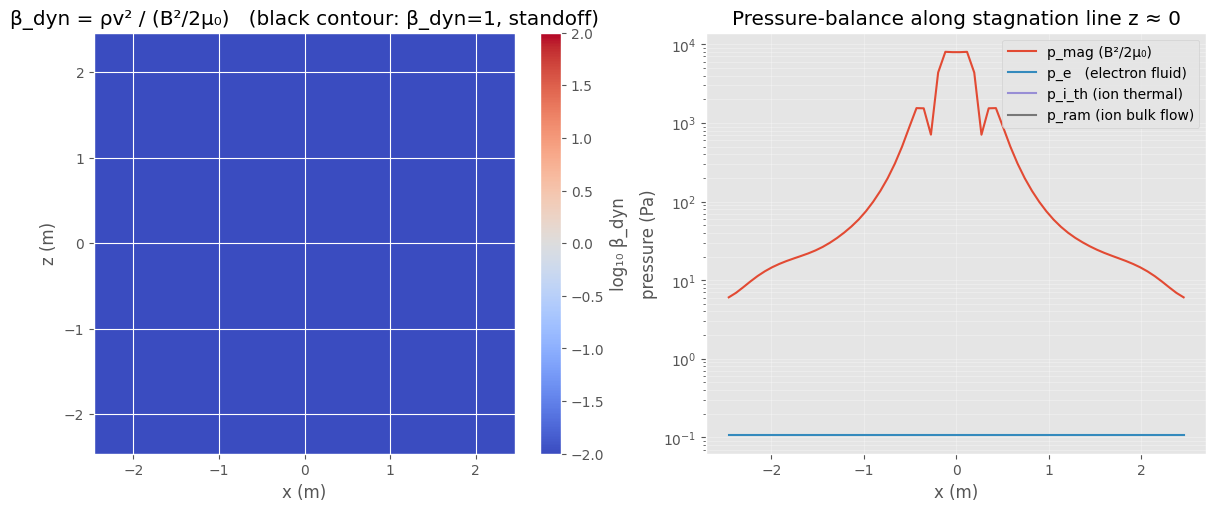

In [10]:
extent = [xs[0], xs[-1], zs[0], zs[-1]]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# β_dyn heatmap + β_dyn = 1 standoff contour
im = axes[0].imshow(
    np.log10(np.maximum(beta_dyn, 1e-3)).T,
    origin="lower", extent=extent, cmap="coolwarm", vmin=-2, vmax=2,
)
axes[0].contour(xs, zs, beta_dyn.T, levels=[1.0], colors="k", linewidths=2)
fig.colorbar(im, ax=axes[0], label="log₁₀ β_dyn")
axes[0].set_title("β_dyn = ρv² / (B²/2μ₀)   (black contour: β_dyn=1, standoff)")
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("z (m)")
axes[0].set_aspect("equal")

# Pressure profiles along the stagnation line z ≈ 0
iz = int(np.argmin(np.abs(zs)))
axes[1].semilogy(xs, p_mag [:, iz], label="p_mag (B²/2μ₀)")
axes[1].semilogy(xs, p_e   [:, iz], label="p_e   (electron fluid)")
axes[1].semilogy(xs, p_i_th[:, iz], label="p_i_th (ion thermal)")
axes[1].semilogy(xs, p_ram [:, iz], label="p_ram (ion bulk flow)")
axes[1].set_xlabel("x (m)")
axes[1].set_ylabel("pressure (Pa)")
axes[1].set_title("Pressure-balance along stagnation line z ≈ 0")
axes[1].legend(loc="best")
axes[1].grid(True, which="both", alpha=0.3)

plt.show()

## Boundary leakage rate vs time

The deck configures a `ParticleBoundaryScrapingDiagnostic` (`name="scrape"`) that records every macroparticle absorbed at the four field boundaries (`x_lo`, `x_hi`, `z_lo`, `z_hi`), writing to a **separate** openPMD series at `diags/scrape/openpmd_%T.h5`. Each scraped particle carries:

| Record | What it's for |
|---|---|
| `position.{x, z}` | Which face it crossed (mask by threshold near each edge) |
| `momentum.{x, y, z}` | Energy-loss diagnostics if you want them (`E_kin = ½ m_i \|v\|²`) |
| `weighting` | Physical particles per macroparticle — what to **sum** for a count |
| `stepScraped` | PIC step at which the particle was removed — divide by `const_dt` for time |

The output is flushed every `PERIOD = 10` steps, but each particle's `stepScraped` gives per-step time resolution regardless.

Three plots out of one aggregation pass:

1. **Total leakage rate per species** — `background_i` vs `stream_i`, particles/s vs time.
2. **Per-face stacked rate** — which boundary is doing the leaking. For coil_2D, expect `x_lo` (downstream of the stream) to dominate after the front transits; `z_lo` / `z_hi` light up when cusp-channel losses appear.
3. **Cumulative leakage** — sanity-check vs the injected flux `n_stream · v_drift · A_inject · t`. Steady state ⇔ cumulative loss tracks injection.

The cell below is **defensive**: if `diags/scrape/` doesn't exist yet (no run has written it), it prints a hint and skips, so the rest of the notebook keeps executing.

In [11]:
import os
import glob
import openpmd_api as io
import scipy.constants as sc

# Physical domain extents from the deck — only used for the injected-flux
# reference in the plot cell. The "which face?" classification no longer
# relies on position thresholds: WarpX's BoundaryScrapingDiagnostic writes
# one subdirectory per boundary, so the directory name IS the face.
Lx_DOMAIN = 2.5
Lz_DOMAIN = 2.5

SPECIES = ("background_i", "stream_i")
SCRAPE_DIR = "diags/scrape"

# WarpX's BoundaryScrapingDiagnostic with openPMD format writes one
# subdirectory per active boundary, each its own `openpmd_%T.h5` series:
#   diags/scrape/particles_at_xlo/openpmd_*.h5
#   diags/scrape/particles_at_xhi/openpmd_*.h5
#   diags/scrape/particles_at_zlo/openpmd_*.h5
#   diags/scrape/particles_at_zhi/openpmd_*.h5
# Map each canonical face label to its subdirectory.
BOUNDARY_DIRS = {
    "x_lo": "particles_at_xlo",
    "x_hi": "particles_at_xhi",
    "z_lo": "particles_at_zlo",
    "z_hi": "particles_at_zhi",
}
FACES = tuple(BOUNDARY_DIRS)


def _load_component(record_component):
    """Load an openPMD record component as float64, or None if it's empty.

    Empty species in a given iteration are written as constant/zero-extent
    records that have no real data to chunk-load — return None for those.
    """
    try:
        if getattr(record_component, "empty", False):
            return None
        chunk = record_component.load_chunk()
    except (KeyError, IndexError, RuntimeError):
        return None
    return chunk


def _aggregate_scrape(scrape_dir, species_list):
    """Walk every boundary subdirectory and concatenate scraped particles
    per species, tagging each particle with the face it crossed (from the
    subdirectory it came from).

    Returns dict[species] → dict of arrays (incl. a "face" label array)
    plus the common dt pulled from the openPMD iteration attribute.
    """
    buf = {s: {k: [] for k in ("x", "z", "vx", "vy", "vz", "w", "step", "face")}
           for s in species_list}
    dt = None

    for face, subdir in BOUNDARY_DIRS.items():
        pattern = os.path.join(scrape_dir, subdir, "openpmd_%T.h5")
        if not glob.glob(os.path.join(scrape_dir, subdir, "openpmd_*.h5")):
            continue
        series = io.Series(pattern, io.Access.read_only)
        for it_idx in sorted(series.iterations):
            iteration = series.iterations[it_idx]
            if dt is None:
                dt = float(iteration.dt)
            for sp_name in species_list:
                if sp_name not in iteration.particles:
                    continue
                sp = iteration.particles[sp_name]
                x  = _load_component(sp["position"]["x"])
                z  = _load_component(sp["position"]["z"])
                px = _load_component(sp["momentum"]["x"])
                py = _load_component(sp["momentum"]["y"])
                pz = _load_component(sp["momentum"]["z"])
                w  = _load_component(
                    sp["weighting"][io.Mesh_Record_Component.SCALAR])
                step = _load_component(
                    sp["stepScraped"][io.Mesh_Record_Component.SCALAR])
                series.flush()
                # Nothing scraped for this species this period.
                if x is None or len(x) == 0 or w is None:
                    continue
                buf[sp_name]["x"].append(x.astype(np.float64))
                buf[sp_name]["z"].append(z.astype(np.float64))
                buf[sp_name]["vx"].append(px.astype(np.float64) / sc.m_p)
                buf[sp_name]["vy"].append(py.astype(np.float64) / sc.m_p)
                buf[sp_name]["vz"].append(pz.astype(np.float64) / sc.m_p)
                buf[sp_name]["w"].append(w.astype(np.float64))
                buf[sp_name]["step"].append(step.astype(np.float64))
                buf[sp_name]["face"].append(np.full(len(x), face))

    out = {}
    for sp_name, d in buf.items():
        if not d["x"]:
            out[sp_name] = None
            continue
        out[sp_name] = {k: np.concatenate(v) for k, v in d.items()}
        out[sp_name]["time"] = out[sp_name]["step"].astype(float) * dt
    return out, dt


def _scrape_has_data(scrape_dir):
    """True iff at least one boundary subdir holds an openPMD series."""
    return any(
        glob.glob(os.path.join(scrape_dir, subdir, "openpmd_*.h5"))
        for subdir in BOUNDARY_DIRS.values()
    )


# ---- Defensive load ------------------------------------------------------
if not os.path.isdir(SCRAPE_DIR) or not _scrape_has_data(SCRAPE_DIR):
    # Most common cause: the species in inputs/coil 2D/coil_2d.py are missing
    # the `warpx_save_particles_at_<face>=1` flags. The diagnostic itself
    # being configured is necessary but not sufficient — the per-species
    # flags populate the buffer that the diagnostic flushes.
    print(f"[skip] no scrape output found at {SCRAPE_DIR}/.")
    print("       Possible causes (in order of likelihood):")
    print(f"         1. {SCRAPE_DIR}/particles_at_*/ does not exist yet — "
          f"re-run coil_2d.py")
    print(f"            with the species flags ("
          f"warpx_save_particles_at_{{xlo,xhi,zlo,zhi}}=1).")
    print(f"         2. Output layout differs from the expected per-boundary "
          f"`particles_at_*/openpmd_%T.h5` series.")
    scraped = None
    dt_run  = None
else:
    scraped, dt_run = _aggregate_scrape(SCRAPE_DIR, SPECIES)
    total_macros = sum(0 if d is None else len(d["w"]) for d in scraped.values())
    total_phys   = sum(0 if d is None else d["w"].sum() for d in scraped.values())
    t_max_us = max((d["time"].max() for d in scraped.values() if d is not None),
                   default=0.0) * 1e6
    print(f"const_dt              = {dt_run:.3e} s")
    print(f"scraped macroparticles = {total_macros}")
    print(f"scraped physical ions  = {total_phys:.3e}")
    print(f"final t (scraped)      = {t_max_us:.3f} µs")


# ---- Bin scrape events into time histograms -----------------------------
def _binned_rates(scraped, dt, n_bins=80):
    """For each species, return rate(t) total + per-face."""
    if scraped is None:
        return None
    # Common bin edges across all species so the time axes line up
    t_max = max(d["time"].max() for d in scraped.values() if d is not None)
    t_edges = np.linspace(0.0, max(t_max, dt), n_bins + 1)
    bin_dt  = t_edges[1] - t_edges[0]
    t_centers = 0.5 * (t_edges[:-1] + t_edges[1:])

    total = {}
    per_face = {}
    cumulative = {}
    for sp, d in scraped.items():
        if d is None:
            total[sp] = np.zeros_like(t_centers)
            per_face[sp] = {f: np.zeros_like(t_centers) for f in FACES}
            cumulative[sp] = np.zeros_like(t_centers)
            continue
        hist, _ = np.histogram(d["time"], bins=t_edges, weights=d["w"])
        total[sp] = hist / bin_dt
        cumulative[sp] = np.cumsum(hist)
        per_face[sp] = {}
        for fname in FACES:
            m = d["face"] == fname
            h, _ = np.histogram(d["time"][m], bins=t_edges, weights=d["w"][m])
            per_face[sp][fname] = h / bin_dt

    return t_centers, t_edges, total, per_face, cumulative


leakage = _binned_rates(scraped, dt_run) if scraped is not None else None

const_dt              = 1.000e+00 s
scraped macroparticles = 149480
scraped physical ions  = 5.255e+18
final t (scraped)      = 1000000000.000 µs


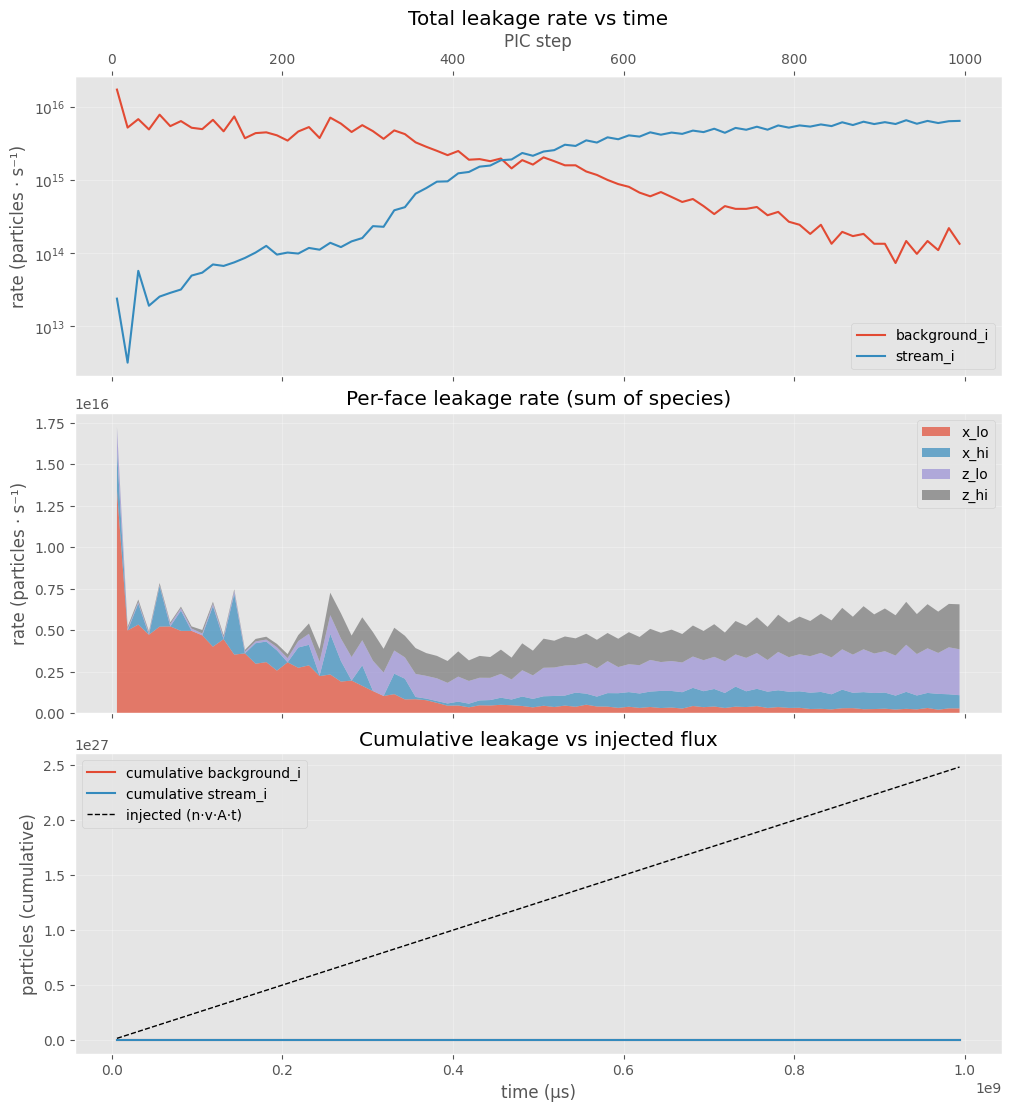

In [12]:
if leakage is None:
    print("[skip] no leakage data — re-run the notebook after the simulation "
          "has written diags/scrape/.")
else:
    t_centers, t_edges, total, per_face, cumulative = leakage
    t_us = t_centers * 1e6

    fig, axes = plt.subplots(3, 1, figsize=(10, 11),
                             sharex=True, constrained_layout=True)

    # ---- (1) Total leakage rate per species ---------------------------------
    for sp in SPECIES:
        axes[0].plot(t_us, total[sp], label=sp, linewidth=1.5)
    axes[0].set_ylabel("rate (particles · s⁻¹)")
    axes[0].set_title("Total leakage rate vs time")
    axes[0].set_yscale("symlog", linthresh=1.0)
    axes[0].grid(alpha=0.3)
    axes[0].legend(loc="best")

    # ---- (2) Per-face stacked rate (both species combined) ------------------
    faces = ("x_lo", "x_hi", "z_lo", "z_hi")
    face_total = {f: sum(per_face[sp][f] for sp in SPECIES) for f in faces}
    axes[1].stackplot(t_us,
                      [face_total[f] for f in faces],
                      labels=faces, alpha=0.7)
    axes[1].set_ylabel("rate (particles · s⁻¹)")
    axes[1].set_title("Per-face leakage rate (sum of species)")
    axes[1].grid(alpha=0.3)
    axes[1].legend(loc="upper right")

    # ---- (3) Cumulative leakage, with injection reference -------------------
    for sp in SPECIES:
        axes[2].plot(t_us, cumulative[sp], label=f"cumulative {sp}",
                     linewidth=1.5)
    # Reference: undisturbed injected flux at the x_hi face. flux × area × t.
    # 2D area = 2·Lz × 1 m (the suppressed y-direction). n·v must match the
    # deck stream params in coil_2d.py (n_stream=1e19, v_drift=5e4).
    injected_ref = 1.0e19 * 5.0e4 * (2.0 * Lz_DOMAIN) * t_centers
    axes[2].plot(t_us, injected_ref, "k--",
                 label="injected (n·v·A·t)", linewidth=1.0)
    axes[2].set_xlabel("time (µs)")
    axes[2].set_ylabel("particles (cumulative)")
    axes[2].set_title("Cumulative leakage vs injected flux")
    axes[2].grid(alpha=0.3)
    axes[2].legend(loc="best")

    # Top x-axis: PIC step number (step = time / const_dt)
    def t_to_step(t):     return t * 1e-6 / dt_run
    def step_to_t(step):  return step * dt_run * 1e6
    sec_ax = axes[0].secondary_xaxis("top", functions=(t_to_step, step_to_t))
    sec_ax.set_xlabel("PIC step")

    plt.show()